<a href="https://colab.research.google.com/github/CopeliaMinutti94/Katachi-MaNGA-Multimodal/blob/main/notebooks/Katachi_Morfologia_Color_Masa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento: incorporación de morfología y color (g-i) para la predicción de masa estelar

## Paso 1. Carga e inspección inicial del catálogo de morfología y color

### ¿Qué se hace?

En este paso se carga el archivo `color_morp.csv`, que contiene información adicional de las galaxias de la muestra de MaNGA.

La tabla incluye, entre otras variables:

- `MANGAID`: identificador único de cada galaxia en MaNGA.
- `T_11`: clasificación morfológica numérica de la galaxia.
- `g_i`: color fotométrico de la galaxia, calculado a partir de las bandas `g` e `i`.

En esta primera etapa únicamente se carga la tabla y se revisan sus dimensiones, nombres de columnas y primeras filas.

### ¿Por qué se hace?

Antes de utilizar estos datos como información adicional para una red neuronal, es necesario comprobar cómo está estructurado el catálogo y verificar qué variables contiene realmente.

Esto permite detectar desde el inicio posibles problemas como:

- valores faltantes;
- nombres de columnas diferentes a los esperados;
- valores fuera de rango;
- identificadores incorrectos o duplicados.

### ¿Para qué se hace?

El objetivo posterior será evaluar si proporcionar explícitamente a Katachi información sobre la **morfología** y el **color (g-i)** de cada galaxia puede mejorar la predicción de su **masa estelar**.

La comparación se realizará posteriormente contra el modelo original de Katachi, que servirá como referencia o *baseline*.

En este punto todavía no se modifica ni se entrena ninguna red neuronal.

### ¿Cómo se hace?

El archivo `color_morp.csv` se carga como un `DataFrame` de Pandas. Después se inspeccionan:

1. El número de filas y columnas.
2. Los nombres de las variables disponibles.
3. Las primeras galaxias del catálogo.

No se realiza todavía ninguna limpieza, filtrado ni transformación de los datos.

In [ ]:
import pandas as pd
from google.colab import files

# Subir el archivo que compartió el Dr.
uploaded = files.upload()

# Leer la tabla
color_morp = pd.read_csv("color_morp.csv")

print("Archivo cargado correctamente")
print("Dimensiones:", color_morp.shape)

print("\nColumnas:")
print(color_morp.columns.tolist())

print("\nPrimeras 5 filas:")
display(color_morp.head())

Saving color_morp.csv to color_morp.csv
Archivo cargado correctamente
Dimensiones: (10126, 4)

Columnas:
['name', 'MANGAID', 'T_11', 'g_i']

Primeras 5 filas:


,name,MANGAID,T_11,g_i
0,manga-10001-12701,1-48157,4,0.404967
1,manga-10001-12702,1-48188,4,0.644865
2,manga-10001-12703,1-55648,4,0.710236
3,manga-10001-12704,1-55616,7,0.766408
4,manga-10001-12705,1-55784,4,0.574194


## Paso 2. Revisión de calidad de las variables de morfología y color

### ¿Qué se hace?

En este paso se realiza una inspección de calidad del catálogo antes de utilizar sus variables en el modelo.

Se revisan específicamente:

- el tipo de dato de cada columna;
- la existencia de valores faltantes;
- posibles `MANGAID` duplicados;
- los valores disponibles de la variable morfológica `T_11`;
- la distribución básica del color `g_i`;
- cuántas galaxias presentan un valor de `g_i > 2`.

### ¿Por qué se hace?

Antes de incorporar nuevas variables a una red neuronal es necesario verificar que los datos sean consistentes.

En particular, se indicó que los valores de color `g_i` mayores a 2 no deben considerarse físicamente válidos para este análisis. Por ello, primero se debe cuantificar cuántos objetos presentan este problema antes de decidir cómo tratarlos.

También es necesario comprobar que el identificador `MANGAID` pueda utilizarse posteriormente para realizar el cruce con las galaxias empleadas por Katachi.

### ¿Para qué se hace?

Esta revisión permitirá definir posteriormente una muestra limpia en la que cada galaxia tenga:

- un identificador MaNGA válido;
- una clasificación morfológica utilizable;
- un valor de color `g_i` válido.

Esto es necesario antes de construir el conjunto de datos que se utilizará para probar si la morfología y el color pueden mejorar la predicción de masa estelar.

### ¿Cómo se hace?

Se utilizan funciones de Pandas para:

1. revisar los tipos de datos;
2. contar valores faltantes;
3. detectar identificadores duplicados;
4. obtener los valores y frecuencias de `T_11`;
5. calcular estadísticas descriptivas de `g_i`;
6. contar específicamente los casos donde `g_i > 2`.

En este paso únicamente se diagnostican los datos.  
Todavía no se elimina ni modifica ninguna galaxia.

In [ ]:
# ============================================================
# PASO 2 — REVISIÓN DE CALIDAD DEL CATÁLOGO
# ============================================================

print("=== TIPOS DE DATOS ===")
print(color_morp.dtypes)


print("\n=== VALORES FALTANTES ===")
print(color_morp.isna().sum())


print("\n=== MANGAID DUPLICADOS ===")
print("Número de MANGAID duplicados:",
      color_morp["MANGAID"].duplicated().sum())


print("\n=== VALORES DE T_11 ===")
print("Valores únicos:")
print(sorted(color_morp["T_11"].dropna().unique()))

print("\nNúmero de galaxias por T_11:")
print(color_morp["T_11"].value_counts(dropna=False).sort_index())


print("\n=== ESTADÍSTICAS DE g_i ===")
print(color_morp["g_i"].describe())


print("\n=== REVISIÓN DEL LÍMITE g_i > 2 ===")
print("Galaxias con g_i > 2:",
      (color_morp["g_i"] > 2).sum())

print("Galaxias con g_i <= 2:",
      (color_morp["g_i"] <= 2).sum())

print("Galaxias sin g_i:",
      color_morp["g_i"].isna().sum())

=== TIPOS DE DATOS ===
name        object
MANGAID     object
T_11         int64
g_i        float64
dtype: object

=== VALORES FALTANTES ===
name          0
MANGAID       0
T_11          0
g_i        1309
dtype: int64

=== MANGAID DUPLICADOS ===
Número de MANGAID duplicados: 0

=== VALORES DE T_11 ===
Valores únicos:
[np.int64(-5), np.int64(-2), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Número de galaxias por T_11:
T_11
-5     1809
-2     1317
 0      615
 1     1085
 2     1051
 3     1126
 4     1034
 5     1026
 6      462
 7      352
 8       79
 9       84
 10      19
 11      67
Name: count, dtype: int64

=== ESTADÍSTICAS DE g_i ===
count    8817.000000
mean        5.394989
std        89.517869
min        -0.908513
25%         0.577530
50%         0.833678
75%         0.989281
max      2099.753250
Name: g_i, dtype: float64

=== REVISIÓN DEL LÍMITE g_i > 2 ===
Galaxi

## Paso 3. Definición de los grupos morfológicos y validación del color

### ¿Qué se hace?

En este paso se crean variables auxiliares a partir de la información original del catálogo.

Para la morfología se utilizará la división propuesta para este experimento:

- **Tempranas:** valores de `T_11` entre -5 y 0.
- **Tardías:** valores de `T_11` entre 1 y 10.
- Los objetos con `T_11 = 11` se conservarán en el catálogo, pero no se asignarán a ninguno de los dos grupos en esta primera prueba.

Para el color `g_i`, se marcarán como válidos únicamente los valores disponibles que cumplan `g_i <= 2`, siguiendo la indicación proporcionada para esta muestra.

### ¿Por qué se hace?

La clasificación morfológica original contiene varios tipos de galaxias. Para realizar una primera prueba controlada, se simplifica esta información a dos grandes grupos: tempranas y tardías.

Asimismo, la inspección inicial mostró valores extremos de `g_i` que llegan hasta valores muy superiores a 2, además de valores faltantes. Estos datos no deben incorporarse directamente al modelo sin identificarlos previamente.

### ¿Para qué se hace?

El objetivo es preparar variables consistentes que posteriormente puedan cruzarse con las galaxias utilizadas por Katachi.

Esto permitirá conocer cuántas galaxias de los conjuntos Train y Test de Katachi disponen simultáneamente de:

1. una clasificación morfológica temprana o tardía;
2. un color `g_i` válido.

Todavía no se elimina ninguna galaxia ni se modifica la arquitectura de la red neuronal.

### ¿Cómo se hace?

Se crearán dos nuevas columnas:

- `grupo_morfologico`: con las etiquetas `Temprana`, `Tardia` o `No_clasificada`.
- `gi_valido`: variable booleana que será `True` cuando exista un valor de `g_i` y este sea menor o igual a 2.

Las columnas originales `T_11` y `g_i` se conservarán sin modificaciones.

In [ ]:
# ============================================================
# PASO 3 — CREAR GRUPOS MORFOLÓGICOS Y BANDERA DE COLOR VÁLIDO
# ============================================================

import numpy as np

# Trabajamos sobre una copia para conservar intacto el catálogo original
color_morp_preparado = color_morp.copy()


# ------------------------------------------------------------
# 1. Crear grupo morfológico
# ------------------------------------------------------------

color_morp_preparado["grupo_morfologico"] = np.select(
    [
        color_morp_preparado["T_11"].between(-5, 0),
        color_morp_preparado["T_11"].between(1, 10)
    ],
    [
        "Temprana",
        "Tardia"
    ],
    default="No_clasificada"
)


# ------------------------------------------------------------
# 2. Crear indicador de color g-i válido
# ------------------------------------------------------------

color_morp_preparado["gi_valido"] = (
    color_morp_preparado["g_i"].notna()
    & (color_morp_preparado["g_i"] <= 2)
)


# ------------------------------------------------------------
# 3. Revisar resultados
# ------------------------------------------------------------

print("=== GRUPOS MORFOLÓGICOS ===")
print(color_morp_preparado["grupo_morfologico"].value_counts())


print("\n=== COLOR g-i ===")
print(color_morp_preparado["gi_valido"].value_counts())


print("\n=== COMBINACIÓN MORFOLOGÍA + COLOR ===")

condicion_completa = (
    color_morp_preparado["grupo_morfologico"].isin(["Temprana", "Tardia"])
    & color_morp_preparado["gi_valido"]
)

print(
    "Galaxias con morfología temprana/tardía Y g-i válido:",
    condicion_completa.sum()
)

print(
    "Galaxias que no cumplen ambas condiciones:",
    (~condicion_completa).sum()
)


print("\nPrimeras filas:")
display(
    color_morp_preparado[
        ["MANGAID", "T_11", "grupo_morfologico", "g_i", "gi_valido"]
    ].head(10)
)

=== GRUPOS MORFOLÓGICOS ===
grupo_morfologico
Tardia            6318
Temprana          3741
No_clasificada      67
Name: count, dtype: int64

=== COLOR g-i ===
gi_valido
True     8653
False    1473
Name: count, dtype: int64

=== COMBINACIÓN MORFOLOGÍA + COLOR ===
Galaxias con morfología temprana/tardía Y g-i válido: 8607
Galaxias que no cumplen ambas condiciones: 1519

Primeras filas:


,MANGAID,T_11,grupo_morfologico,g_i,gi_valido
0,1-48157,4,Tardia,0.404967,True
1,1-48188,4,Tardia,0.644865,True
2,1-55648,4,Tardia,0.710236,True
3,1-55616,7,Tardia,0.766408,True
4,1-55784,4,Tardia,0.574194,True
5,1-55567,4,Tardia,0.792386,True
6,1-48201,-2,Temprana,1.076391,True
7,1-48111,-2,Temprana,0.861452,True
8,1-48136,-5,Temprana,0.536094,True
9,1-55612,3,Tardia,0.583124,True


## Paso 4. Recuperación de la muestra utilizada por Katachi

### ¿Qué se hace?

En este paso se carga el catálogo `scalars.cat` del repositorio original de Katachi.

Este catálogo contiene información sobre las galaxias consideradas por el proyecto, incluyendo la variable `split`, que permite identificar cuáles objetos fueron utilizados en los conjuntos:

- `Train`: entrenamiento.
- `Test`: prueba.
- `None`: objetos que no fueron asignados a ninguno de los dos conjuntos.

Se seleccionarán únicamente las galaxias pertenecientes a `Train` o `Test`.

### ¿Por qué se hace?

El catálogo de morfología y color contiene 10,126 galaxias, pero Katachi no utiliza todas ellas.

Para realizar un experimento comparable con el modelo original, es necesario trabajar exactamente con la muestra utilizada por Katachi y conservar la división original entre entrenamiento y prueba.

Modificar esta división podría producir una comparación injusta con el modelo de referencia.

### ¿Para qué se hace?

El objetivo es recuperar los identificadores `MANGAID` de las 9,904 galaxias utilizadas por Katachi y su correspondiente asignación a `Train` o `Test`.

Posteriormente, estos identificadores se utilizarán para cruzar la muestra de Katachi con el catálogo de morfología y color.

### ¿Cómo se hace?

1. Se obtiene el repositorio de Katachi.
2. Se instala la librería `hickle`, utilizada para leer `scalars.cat`.
3. Se carga el catálogo como un DataFrame de Pandas.
4. Se revisa la columna `split`.
5. Se seleccionan únicamente los objetos con `split = Train` o `split = Test`.

En este paso todavía no se realiza el cruce con `color_morp.csv`.

In [ ]:
import os

ruta_catalogos = "/content/Katachi/Catalogues"

print("Contenido actual de Catalogues:")
for archivo in os.listdir(ruta_catalogos):
    print(archivo)

Contenido actual de Catalogues:
place_holder.txt


### Paso 4A. Identificación del procedimiento oficial para descargar los archivos grandes de Katachi

#### ¿Qué se hace?

El repositorio recién clonado no contiene directamente el archivo `scalars.cat`. En la carpeta `Catalogues` únicamente aparece `place_holder.txt`.

Sin embargo, el repositorio de Katachi incluye el notebook `get_large_files.ipynb`, destinado a obtener los archivos de gran tamaño que no se descargan con un `git clone` normal.

#### ¿Por qué se hace?

`scalars.cat` es necesario para recuperar la muestra original de galaxias utilizada por Katachi y su división Train/Test.

Antes de descargar archivos externos, se revisará el procedimiento proporcionado por los propios autores del repositorio, evitando asumir rutas o enlaces.

#### ¿Para qué se hace?

El objetivo es obtener `scalars.cat` de la misma fuente utilizada por Katachi y continuar posteriormente con el cruce entre:

- las galaxias utilizadas por Katachi;
- la morfología;
- el color `g-i`.

#### ¿Cómo se hace?

Se leerán las celdas de código de `get_large_files.ipynb` para identificar qué comando utilizan los autores para descargar los archivos grandes.

En esta etapa todavía no se realiza ninguna descarga.

In [ ]:
import json

ruta_notebook = "/content/Katachi/get_large_files.ipynb"

with open(ruta_notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("=== CELDAS DE CÓDIGO DE get_large_files.ipynb ===\n")

for i, celda in enumerate(nb["cells"]):
    if celda["cell_type"] == "code":
        codigo = "".join(celda["source"])
        print(f"\n--- CELDA {i} ---")
        print(codigo)

=== CELDAS DE CÓDIGO DE get_large_files.ipynb ===


--- CELDA 1 ---
import os 
import wget

--- CELDA 2 ---
work_dir = 'PUT DIRECTORY OF KATACHI FOLDER HERE'
work_dir1 = work_dir+'\Catalogues'

def download_with_wget(url, destination_directory, filename):
    try:
        full_path = f"{destination_directory}/{filename}"
        wget.download(url, out=full_path)
        print(f"Downloaded file saved as: {full_path}")
    except Exception as e:
        print(f"An error occurred: {e}")


#Downloading full data catalogues generated for this work 
manga_scalars = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/scalars.cat',work_dir1, 'scalars')
manga_images = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/images.cat',work_dir1, 'images')
manga_shap_maps_mass = download_with_wget('https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/shap_mass.cat',work_dir1, 'shap_mass')
manga_shap

### Paso 4B. Descarga del catálogo `scalars.cat` de Katachi

#### ¿Qué se hace?

Se descarga el archivo `scalars.cat`, que contiene el catálogo principal utilizado por Katachi.

El archivo se obtiene desde la dirección indicada por los propios autores en el notebook `get_large_files.ipynb` incluido en el repositorio oficial.

#### ¿Por qué se hace?

El archivo `scalars.cat` no está incluido directamente cuando se clona el repositorio de GitHub debido a su tamaño.

Sin este catálogo no es posible recuperar de manera completa la muestra utilizada por Katachi ni identificar correctamente la división original entre `Train` y `Test`.

#### ¿Para qué se hace?

Este catálogo permitirá identificar las 9,904 galaxias utilizadas por Katachi y posteriormente cruzarlas mediante `MANGAID` con el archivo de morfología y color proporcionado para el nuevo experimento.

#### ¿Cómo se hace?

Se descarga directamente el archivo `scalars.cat` desde el servidor utilizado por los autores de Katachi y se guarda dentro de:

`/content/Katachi/Catalogues/scalars.cat`

En este paso solamente se descarga y verifica el archivo. Todavía no se realiza ningún cruce de datos.

In [ ]:
# ============================================================
# PASO 4B — DESCARGAR scalars.cat
# ============================================================

import os

url_scalars = (
    "https://www.astr.tohoku.ac.jp/"
    "~juanpabloalfonzo/Katachi_MaNGA_Catalogues/scalars.cat"
)

ruta_scalars = "/content/Katachi/Catalogues/scalars.cat"

# Descargar solamente si todavía no existe
if not os.path.exists(ruta_scalars):
    !wget -q "$url_scalars" -O "$ruta_scalars"
    print("scalars.cat descargado.")
else:
    print("scalars.cat ya existe.")

# Verificación
print("\n¿Existe el archivo?:", os.path.exists(ruta_scalars))

if os.path.exists(ruta_scalars):
    tam_mb = os.path.getsize(ruta_scalars) / (1024**2)
    print(f"Tamaño: {tam_mb:.2f} MB")
    print("Ruta:", ruta_scalars)

scalars.cat descargado.

¿Existe el archivo?: True
Tamaño: 153.52 MB
Ruta: /content/Katachi/Catalogues/scalars.cat


### Paso 4C. Carga de `scalars.cat` y recuperación de la muestra original de Katachi

#### ¿Qué se hace?

Se carga el catálogo `scalars.cat` descargado desde la fuente indicada por los autores de Katachi.

Después se utiliza la columna `split` para identificar qué galaxias pertenecen a los conjuntos originales:

- `Train`: galaxias utilizadas para entrenamiento.
- `Test`: galaxias utilizadas para evaluación.
- `None`: objetos presentes en el catálogo pero no asignados a ninguno de estos dos conjuntos.

#### ¿Por qué se hace?

El nuevo experimento debe partir de la misma muestra y conservar la división Train/Test utilizada originalmente por Katachi.

Esto es necesario para que posteriormente la comparación entre el modelo original y el modelo con información adicional de morfología y color sea consistente.

#### ¿Para qué se hace?

El objetivo es obtener una tabla con los `MANGAID` de las galaxias efectivamente utilizadas por Katachi y su correspondiente `split`.

Esta tabla servirá en el siguiente paso para realizar el cruce con el catálogo `color_morp.csv`.

#### ¿Cómo se hace?

1. Se carga `scalars.cat` mediante la librería `hickle`.
2. Se inspecciona la distribución de la columna `split`.
3. Se seleccionan únicamente los objetos con `split = Train` o `split = Test`.
4. Se conservan `MANGAID` y `split`.
5. Se comprueba que no existan identificadores faltantes o duplicados.

In [ ]:
# ============================================================
# PASO 4C — CARGAR scalars.cat Y RECUPERAR TRAIN / TEST
# ============================================================

import hickle
import pandas as pd

ruta_scalars = "/content/Katachi/Catalogues/scalars.cat"

# ------------------------------------------------------------
# 1. Cargar catálogo
# ------------------------------------------------------------

scalars = hickle.load(ruta_scalars)

print("scalars.cat cargado correctamente")
print("Dimensiones completas:", scalars.shape)


# ------------------------------------------------------------
# 2. Revisar la división original
# ------------------------------------------------------------

print("\n=== DISTRIBUCIÓN DE split ===")
print(scalars["split"].value_counts(dropna=False))


# ------------------------------------------------------------
# 3. Recuperar únicamente las galaxias usadas por Katachi
# ------------------------------------------------------------

katachi_muestra = (
    scalars[
        scalars["split"].isin(["Train", "Test"])
    ][["mangaid", "split"]]
    .rename(columns={"mangaid": "MANGAID"})
    .copy()
)

katachi_muestra["MANGAID"] = (
    katachi_muestra["MANGAID"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 4. Validaciones
# ------------------------------------------------------------

print("\n=== MUESTRA UTILIZADA POR KATACHI ===")

print("Total:", len(katachi_muestra))

print("\nDistribución Train/Test:")
print(katachi_muestra["split"].value_counts())

print("\nMANGAID faltantes:",
      katachi_muestra["MANGAID"].isna().sum())

print("MANGAID duplicados:",
      katachi_muestra["MANGAID"].duplicated().sum())

print("\nPrimeras filas:")
display(katachi_muestra.head())

scalars.cat cargado correctamente
Dimensiones completas: (10081, 30)

=== DISTRIBUCIÓN DE split ===
split
Train    8914
Test      990
None      177
Name: count, dtype: int64

=== MUESTRA UTILIZADA POR KATACHI ===
Total: 9904

Distribución Train/Test:
split
Train    8914
Test      990
Name: count, dtype: int64

MANGAID faltantes: 0
MANGAID duplicados: 0

Primeras filas:


,MANGAID,split
0,1-1009,Train
1,1-10166,Train
2,1-10177,Train
3,1-10263,Train
4,1-1033,Train


## Paso 5. Cruce de la muestra de Katachi con el catálogo de morfología y color

### ¿Qué se hace?

Se unen dos tablas utilizando `MANGAID` como identificador común:

1. La muestra original utilizada por Katachi:
   - 8,914 galaxias de Train.
   - 990 galaxias de Test.
   - 9,904 galaxias en total.

2. El catálogo `color_morp.csv`, que contiene:
   - `T_11`: clasificación morfológica.
   - `g_i`: color fotométrico.
   - `grupo_morfologico`: clasificación simplificada en temprana o tardía.
   - `gi_valido`: indicador de si el valor de color puede utilizarse.

### ¿Por qué se hace?

El catálogo de morfología y color contiene más galaxias que las utilizadas por Katachi.

Para realizar un experimento comparable con el modelo original, es necesario saber cuáles de las galaxias de Train y Test de Katachi tienen también información de morfología y color.

### ¿Para qué se hace?

El objetivo es determinar el tamaño real de la muestra disponible para probar posteriormente si agregar morfología y color `g-i` mejora la predicción de masa estelar.

También se quiere conocer por separado cuántas galaxias válidas quedan en Train y cuántas en Test.

### ¿Cómo se hace?

Se realiza un `merge` utilizando `MANGAID`.

Se conservan inicialmente las 9,904 galaxias de Katachi, aunque alguna no tenga correspondencia o no tenga datos adicionales válidos.

Después se cuantifica:

1. cuántas aparecen en `color_morp.csv`;
2. cuántas tienen morfología temprana o tardía;
3. cuántas tienen `g_i` válido;
4. cuántas cumplen ambas condiciones;
5. cómo se distribuyen entre Train y Test.

En este paso todavía no se elimina ninguna galaxia ni se modifica la red neuronal.

In [ ]:
# ============================================================
# PASO 5 — CRUCE KATACHI + MORFOLOGÍA + COLOR
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Normalizar MANGAID en ambas tablas
# ------------------------------------------------------------

color_morp_preparado["MANGAID"] = (
    color_morp_preparado["MANGAID"]
    .astype(str)
    .str.strip()
)

katachi_muestra["MANGAID"] = (
    katachi_muestra["MANGAID"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 2. Cruzar las 9904 galaxias de Katachi con color_morp
# ------------------------------------------------------------

katachi_morf_color = katachi_muestra.merge(
    color_morp_preparado[
        [
            "MANGAID",
            "T_11",
            "g_i",
            "grupo_morfologico",
            "gi_valido"
        ]
    ],
    on="MANGAID",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 3. Identificar si la galaxia fue encontrada en color_morp
# ------------------------------------------------------------

katachi_morf_color["en_color_morp"] = (
    katachi_morf_color["T_11"].notna()
)


# ------------------------------------------------------------
# 4. Identificar si la morfología puede usarse
# ------------------------------------------------------------

katachi_morf_color["morfologia_valida"] = (
    katachi_morf_color["grupo_morfologico"]
    .isin(["Temprana", "Tardia"])
)


# ------------------------------------------------------------
# 5. Identificar si tiene ambas variables válidas
# ------------------------------------------------------------

katachi_morf_color["datos_extra_validos"] = (
    katachi_morf_color["morfologia_valida"]
    & katachi_morf_color["gi_valido"].fillna(False)
)


# ------------------------------------------------------------
# 6. Resumen general
# ------------------------------------------------------------

print("=== CRUCE GENERAL ===")

print(
    "Galaxias originales de Katachi:",
    len(katachi_morf_color)
)

print(
    "Encontradas en color_morp.csv:",
    katachi_morf_color["en_color_morp"].sum()
)

print(
    "No encontradas en color_morp.csv:",
    (~katachi_morf_color["en_color_morp"]).sum()
)


print("\n=== DISPONIBILIDAD DE VARIABLES ===")

print(
    "Con morfología temprana/tardía válida:",
    katachi_morf_color["morfologia_valida"].sum()
)

print(
    "Con g-i válido:",
    katachi_morf_color["gi_valido"].fillna(False).sum()
)

print(
    "Con morfología válida Y g-i válido:",
    katachi_morf_color["datos_extra_validos"].sum()
)


# ------------------------------------------------------------
# 7. Resumen por Train y Test
# ------------------------------------------------------------

print("\n=== POR SPLIT ===")

resumen_split = (
    katachi_morf_color
    .groupby("split")
    .agg(
        total=("MANGAID", "size"),
        encontradas=("en_color_morp", "sum"),
        morfologia_valida=("morfologia_valida", "sum"),
        gi_valido=("gi_valido", "sum"),
        ambas_validas=("datos_extra_validos", "sum")
    )
)

display(resumen_split)


# ------------------------------------------------------------
# 8. Distribución morfológica
# ------------------------------------------------------------

print("\n=== GRUPOS MORFOLÓGICOS EN KATACHI ===")

print(
    katachi_morf_color["grupo_morfologico"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 9. Primeras filas
# ------------------------------------------------------------

print("\n=== PRIMERAS FILAS DEL CRUCE ===")

display(
    katachi_morf_color[
        [
            "MANGAID",
            "split",
            "T_11",
            "grupo_morfologico",
            "g_i",
            "gi_valido",
            "datos_extra_validos"
        ]
    ].head(10)
)

=== CRUCE GENERAL ===
Galaxias originales de Katachi: 9904
Encontradas en color_morp.csv: 9897
No encontradas en color_morp.csv: 7

=== DISPONIBILIDAD DE VARIABLES ===
Con morfología temprana/tardía válida: 9832
Con g-i válido: 8494
Con morfología válida Y g-i válido: 8449

=== POR SPLIT ===


/tmp/ipykernel_2184/4153892182.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & katachi_morf_color["gi_valido"].fillna(False)
/tmp/ipykernel_2184/4153892182.py:104: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  katachi_morf_color["gi_valido"].fillna(False).sum()


,total,encontradas,morfologia_valida,gi_valido,ambas_validas
split,,,,,
Test,990,989,983,835,832
Train,8914,8908,8849,7659,7617



=== GRUPOS MORFOLÓGICOS EN KATACHI ===
grupo_morfologico
Tardia            6222
Temprana          3610
No_clasificada      65
NaN                  7
Name: count, dtype: int64

=== PRIMERAS FILAS DEL CRUCE ===


,MANGAID,split,T_11,grupo_morfologico,g_i,gi_valido,datos_extra_validos
0,1-1009,Train,2.0,Tardia,0.720922,True,True
1,1-10166,Train,3.0,Tardia,0.704102,True,True
2,1-10177,Train,2.0,Tardia,0.969820,True,True
3,1-10263,Train,6.0,Tardia,0.462298,True,True
4,1-1033,Train,6.0,Tardia,0.643697,True,True
5,1-1037,Train,5.0,Tardia,0.412423,True,True
6,1-10375,Train,0.0,Temprana,0.410159,True,True
7,1-1038,Train,2.0,Tardia,0.960702,True,True
8,1-10425,Train,-5.0,Temprana,0.876415,True,True
9,1-10550,Train,-5.0,Temprana,0.997942,True,True


## Paso 3A. Validación técnica y física preliminar del color `g-i`

### ¿Qué se hace?

Antes de utilizar el color `g-i` como variable de entrada para la red neuronal, se revisa que su almacenamiento y sus valores sean consistentes.

La validación se realiza en dos niveles:

1. **Validación técnica:** comprobar que `g_i` sea una variable numérica y que no contenga valores infinitos o representaciones incorrectas.
2. **Validación física preliminar:** inspeccionar su rango, valores faltantes y valores extremos.

### ¿Por qué se hace?

Que una columna pueda ser leída por Pandas no significa que todos sus valores sean físicamente utilizables.

En este catálogo, `g_i` está almacenado como número de punto flotante (`float64`), pero la inspección inicial mostró valores extremos muy altos.

Además, se indicó explícitamente que para este análisis los valores de `g_i > 2` no deben considerarse válidos.

### ¿Para qué se hace?

El objetivo es evitar que valores faltantes o físicamente no válidos sean utilizados posteriormente como entradas de la red neuronal.

También se busca documentar de forma reproducible qué criterio se utilizó para decidir qué valores de color pueden formar parte del experimento.

### ¿Cómo se hace?

Se comprueba:

- el tipo de dato de `g_i`;
- la existencia de valores infinitos;
- el número de valores faltantes;
- el valor mínimo y máximo;
- percentiles de la distribución;
- número de objetos con `g_i > 2`;
- número de objetos con valores negativos;
- distribución visual mediante un histograma.

En esta etapa no se modifican los valores originales.

=== VALIDACIÓN TÉCNICA ===
Tipo de dato: float64
¿Es columna numérica?: True
Valores faltantes: 1309
Valores infinitos: 0

=== RANGO DE LOS DATOS ===
Mínimo: -0.9085127999197552
Máximo: 2099.7532500074794

Percentiles:
count    8817.000000
mean        5.394989
std        89.517869
min        -0.908513
1%          0.134403
5%          0.318475
25%         0.577530
50%         0.833678
75%         0.989281
95%         1.149161
99%        49.317454
max      2099.753250
Name: g_i, dtype: float64

=== REVISIÓN SEGÚN EL CRITERIO DEL EXPERIMENTO ===
g_i <= 2: 8653
g_i > 2: 164
g_i negativos: 32
g_i faltantes: 1309

=== EJEMPLOS DE VALORES EXTREMOS ===

10 valores más altos:


,MANGAID,T_11,g_i
5896,50-7,-5,2099.75325
5890,50-2,-5,2099.75276
5894,50-8,-5,2099.73904
8474,46-51,0,2099.73316
7200,40-2,3,2099.72973
9445,43-130,5,2099.72434
717,59-4,3,2099.72091
7063,43-22,9,2099.71454
5895,50-6,-2,2099.71356
8557,46-287,-2,2099.68024



10 valores más bajos:


,MANGAID,T_11,g_i
121,1-383825,5,-0.908513
6819,1-118457,11,-0.818517
6295,1-584598,5,-0.441059
3079,1-79,10,-0.313110
240,1-36585,5,-0.302737
6207,1-92057,1,-0.247827
3887,1-37084,3,-0.202825
7294,1-604172,5,-0.147251
3406,1-120019,6,-0.144887
2074,1-325250,11,-0.135682


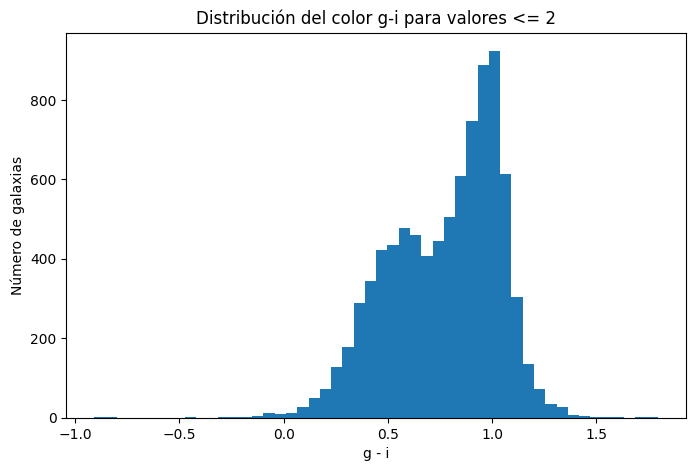

In [ ]:
# ============================================================
# PASO 3A — VALIDACIÓN DEL COLOR g-i
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gi = color_morp["g_i"]

print("=== VALIDACIÓN TÉCNICA ===")

print("Tipo de dato:", gi.dtype)
print("¿Es columna numérica?:", pd.api.types.is_numeric_dtype(gi))

print("Valores faltantes:", gi.isna().sum())

print(
    "Valores infinitos:",
    np.isinf(gi.dropna()).sum()
)


print("\n=== RANGO DE LOS DATOS ===")

print("Mínimo:", gi.min())
print("Máximo:", gi.max())

print("\nPercentiles:")
print(
    gi.describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)


print("\n=== REVISIÓN SEGÚN EL CRITERIO DEL EXPERIMENTO ===")

print("g_i <= 2:",
      (gi <= 2).sum())

print("g_i > 2:",
      (gi > 2).sum())

print("g_i negativos:",
      (gi < 0).sum())

print("g_i faltantes:",
      gi.isna().sum())


print("\n=== EJEMPLOS DE VALORES EXTREMOS ===")

print("\n10 valores más altos:")
display(
    color_morp[
        ["MANGAID", "T_11", "g_i"]
    ]
    .sort_values("g_i", ascending=False)
    .head(10)
)

print("\n10 valores más bajos:")
display(
    color_morp[
        ["MANGAID", "T_11", "g_i"]
    ]
    .sort_values("g_i", ascending=True)
    .head(10)
)


# ------------------------------------------------------------
# Histograma usando únicamente el rango que el doctor considera válido
# ------------------------------------------------------------

gi_visual = gi[
    gi.notna()
    & (gi <= 2)
]

plt.figure(figsize=(8, 5))
plt.hist(gi_visual, bins=50)
plt.xlabel("g - i")
plt.ylabel("Número de galaxias")
plt.title("Distribución del color g-i para valores <= 2")
plt.show()

### Conclusión de la validación de `g_i`

La variable `g_i` está almacenada correctamente como una variable numérica (`float64`) y no presenta valores infinitos.

Sin embargo, se identificaron tres situaciones relevantes:

- 1,309 galaxias no tienen un valor disponible de `g_i`.
- 164 galaxias presentan `g_i > 2`, valores que no se consideran válidos para este experimento.
- 32 galaxias presentan valores negativos de `g_i`. Estos valores no se eliminarán en esta etapa, ya que un color negativo no implica por sí mismo un valor incorrecto y no se indicó un límite inferior para la variable.

Los valores extremadamente altos de `g_i` producen una fuerte distorsión de las estadísticas globales. Por ejemplo, la media de la muestra completa es 5.39, mientras que la mediana es 0.83.

Al visualizar únicamente los valores `g_i <= 2`, la mayor parte de la distribución se concentra aproximadamente en el intervalo esperado para la muestra, sin los valores extremos.

Por lo tanto, para este experimento se conservará el valor original de `g_i`, pero se utilizará una bandera de calidad para identificar como utilizables únicamente los valores disponibles con `g_i <= 2`.

La definición fotométrica exacta y la procedencia de la medida `g_i` deberán documentarse a partir de la fuente original del catálogo antes de describir formalmente esta variable en la metodología.